# Two-Mode Network Analysis: MovieLens 100K
## Island Method for Network Reduction

### Marc Fridson | CUNY SPS | DATA 620

---

## Introduction

This notebook analyzes the **MovieLens 100K** dataset as a bipartite (two-mode) network. The dataset contains 100,000 ratings from 943 users across 1,682 movies, collected by the GroupLens Research Project at the University of Minnesota. It's a natural fit for two-mode network analysis: users and movies are the two distinct node sets, and a rating creates a tie between them. Crucially, there are no direct ties within either group, only between them, which is exactly the structure we need.

The full bipartite graph is dense, so we need a principled way to reduce it. I'm using the **island method** described in Chapter 4 of de Nooy, Mrvar, and Batagelj's *Exploratory Social Network Analysis with Pajek*. The idea is straightforward: project the bipartite network onto each node set to get weighted one-mode networks, then progressively raise a threshold to isolate "islands," connected subgraphs where the weakest internal connection is stronger than any external connection. This surfaces the core clusters without arbitrary cutoffs.

The goal is to reduce the network to its most meaningful structure and see what we can infer about user taste communities and movie groupings.

## 1. Setup and Data Loading

In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from networkx.algorithms import bipartite
from collections import Counter, defaultdict
import community as community_louvain
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')

# Load ratings: user_id, movie_id, rating, timestamp
ratings = pd.read_csv('ml-100k/u.data', sep='\t', 
                       names=['user_id', 'movie_id', 'rating', 'timestamp'])

# Load movie metadata
genre_names = ['unknown','Action','Adventure','Animation',"Children's",'Comedy',
               'Crime','Documentary','Drama','Fantasy','Film-Noir','Horror',
               'Musical','Mystery','Romance','Sci-Fi','Thriller','War','Western']

movie_cols = ['movie_id','title','release_date','video_date','url'] + genre_names
movies = pd.read_csv('ml-100k/u.item', sep='|', names=movie_cols, 
                      encoding='latin-1')

# Load user demographics
users = pd.read_csv('ml-100k/u.user', sep='|', 
                     names=['user_id','age','gender','occupation','zip'])

print(f"Ratings: {len(ratings):,}")
print(f"Users: {ratings['user_id'].nunique():,}")
print(f"Movies: {ratings['movie_id'].nunique():,}")
print(f"Rating distribution:\n{ratings['rating'].value_counts().sort_index()}")

Ratings: 100,000
Users: 943
Movies: 1,682
Rating distribution:
rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64


## 2. Build the Bipartite Network

To keep this computationally tractable while still working with a meaningfully large network, I'm filtering to **positive ratings only** (4 or 5 stars). A 3-star rating is ambivalent, and 1-2 stars represent dislike, neither of which signals a meaningful affinity between a user and a movie. This is a common approach in collaborative filtering and gives us a cleaner signal for the projection step.

In [2]:
# Filter to positive ratings (4-5 stars)
positive = ratings[ratings['rating'] >= 4].copy()
print(f"Positive ratings (4-5 stars): {len(positive):,} ({len(positive)/len(ratings)*100:.1f}% of total)")

# Build bipartite graph
B = nx.Graph()

# Add user nodes (bipartite=0)
user_ids = positive['user_id'].unique()
for uid in user_ids:
    B.add_node(f"u_{uid}", bipartite=0, node_type='user')

# Add movie nodes (bipartite=1)
movie_ids = positive['movie_id'].unique()
for mid in movie_ids:
    title = movies.loc[movies['movie_id'] == mid, 'title'].values
    title = title[0] if len(title) > 0 else f"Movie {mid}"
    B.add_node(f"m_{mid}", bipartite=1, node_type='movie', title=title, movie_id=mid)

# Add edges (user rated movie positively)
for _, row in positive.iterrows():
    B.add_edge(f"u_{row['user_id']}", f"m_{row['movie_id']}", rating=row['rating'])

user_nodes = {n for n, d in B.nodes(data=True) if d['bipartite'] == 0}
movie_nodes = set(B) - user_nodes

print(f"\nBipartite graph: {len(user_nodes)} users, {len(movie_nodes)} movies, {B.number_of_edges():,} edges")
print(f"Density: {bipartite.density(B, user_nodes):.4f}")
print(f"Is bipartite: {nx.is_bipartite(B)}")

Positive ratings (4-5 stars): 55,375 (55.4% of total)



Bipartite graph: 942 users, 1447 movies, 55,375 edges
Density: 0.0406
Is bipartite: True


## 3. One-Mode Projections

Projecting a bipartite network onto each mode gives us two weighted one-mode networks. The **user projection** connects two users if they both rated the same movie positively, with the edge weight being the count of shared movies. The **movie projection** connects two movies if the same user rated both positively, weighted by the number of shared users. These weighted projections are what we'll feed into the island method.

In [3]:
# Weighted one-mode projections
user_proj = bipartite.weighted_projected_graph(B, user_nodes)
movie_proj = bipartite.weighted_projected_graph(B, movie_nodes)

print("=== User Projection ===")
print(f"Nodes: {user_proj.number_of_nodes()}, Edges: {user_proj.number_of_edges():,}")
user_weights = [d['weight'] for _, _, d in user_proj.edges(data=True)]
print(f"Edge weight range: {min(user_weights)} to {max(user_weights)}")
print(f"Mean weight: {np.mean(user_weights):.2f}, Median: {np.median(user_weights):.1f}")

print(f"\n=== Movie Projection ===")
print(f"Nodes: {movie_proj.number_of_nodes()}, Edges: {movie_proj.number_of_edges():,}")
movie_weights = [d['weight'] for _, _, d in movie_proj.edges(data=True)]
print(f"Edge weight range: {min(movie_weights)} to {max(movie_weights)}")
print(f"Mean weight: {np.mean(movie_weights):.2f}, Median: {np.median(movie_weights):.1f}")

=== User Projection ===
Nodes: 942, Edges: 382,442
Edge weight range: 1 to 179
Mean weight: 9.05, Median: 5.0

=== Movie Projection ===
Nodes: 1447, Edges: 460,019


Edge weight range: 1 to 349
Mean weight: 6.54, Median: 2.0


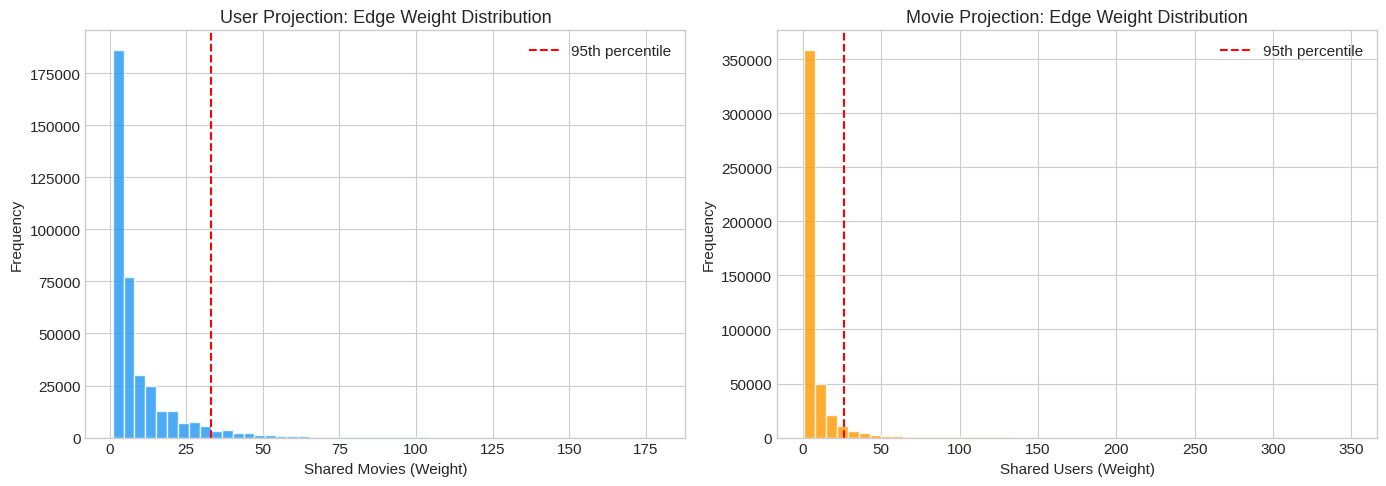

In [4]:
# Distribution of edge weights
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_weights, bins=50, color='#2196F3', alpha=0.8, edgecolor='white')
axes[0].set_title('User Projection: Edge Weight Distribution', fontsize=13)
axes[0].set_xlabel('Shared Movies (Weight)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.percentile(user_weights, 95), color='red', linestyle='--', label='95th percentile')
axes[0].legend()

axes[1].hist(movie_weights, bins=50, color='#FF9800', alpha=0.8, edgecolor='white')
axes[1].set_title('Movie Projection: Edge Weight Distribution', fontsize=13)
axes[1].set_xlabel('Shared Users (Weight)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.percentile(movie_weights, 95), color='red', linestyle='--', label='95th percentile')
axes[1].legend()

plt.tight_layout()
plt.savefig('weight_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Island Method for Network Reduction

The island method (de Nooy, Mrvar & Batagelj, Chapter 4) is a systematic approach to reducing a valued network to its core structure. The algorithm works by progressively raising a threshold on edge weights and identifying connected components, or "islands," at each level. An island at threshold *t* is a maximal connected subgraph where every internal edge has weight ≥ *t*. The key insight is that islands represent cohesive clusters where the weakest internal bond is still stronger than any connection to the outside.

This is conceptually similar to hierarchical clustering but operates directly on the network topology, which makes it a natural fit for social network data where we care about structural cohesion, not just distance.

In [5]:
def island_method(G, min_island_size=3):
    """
    Implement the island method for network reduction.
    
    For each threshold t (from high to low):
      1. Keep only edges with weight >= t
      2. Find connected components
      3. A component is an island at level t if it has >= min_island_size nodes
         and it's the highest threshold where this component appears as connected
    
    Returns islands sorted by threshold (strongest first).
    """
    weights = sorted(set(d['weight'] for _, _, d in G.edges(data=True)), reverse=True)
    
    islands = []
    seen_node_sets = []
    
    for threshold in weights:
        # Create subgraph with edges >= threshold
        edges_above = [(u, v, d) for u, v, d in G.edges(data=True) if d['weight'] >= threshold]
        H = nx.Graph()
        H.add_nodes_from(G.nodes(data=True))
        H.add_edges_from(edges_above)
        
        # Find connected components
        for comp in nx.connected_components(H):
            if len(comp) < min_island_size:
                continue
            
            # Check if this component is a subgraph with actual edges
            sub = H.subgraph(comp)
            if sub.number_of_edges() == 0:
                continue
            
            # Check this isn't a subset of an already-found island at a higher threshold
            frozen = frozenset(comp)
            is_new = True
            for seen in seen_node_sets:
                if frozen == seen or frozen.issubset(seen):
                    is_new = False
                    break
            
            if is_new:
                min_internal = min(d['weight'] for _, _, d in sub.edges(data=True))
                max_internal = max(d['weight'] for _, _, d in sub.edges(data=True))
                avg_internal = np.mean([d['weight'] for _, _, d in sub.edges(data=True)])
                
                islands.append({
                    'threshold': threshold,
                    'nodes': comp,
                    'size': len(comp),
                    'edges': sub.number_of_edges(),
                    'min_weight': min_internal,
                    'max_weight': max_internal,
                    'avg_weight': avg_internal,
                    'density': nx.density(sub)
                })
                seen_node_sets.append(frozen)
    
    # Sort by threshold descending, then by size descending
    islands.sort(key=lambda x: (-x['threshold'], -x['size']))
    return islands

print("Island method defined. Running on both projections...")

Island method defined. Running on both projections...


### 4.1 Island Method on User Projection

In [6]:
# Run island method on user projection
user_islands = island_method(user_proj, min_island_size=3)

print(f"Found {len(user_islands)} user islands\n")
print(f"{'Island':<8} {'Threshold':<12} {'Size':<8} {'Edges':<8} {'Density':<10} {'Avg Weight':<12}")
print("-" * 60)
for i, island in enumerate(user_islands[:15]):
    print(f"{i+1:<8} {island['threshold']:<12} {island['size']:<8} {island['edges']:<8} "
          f"{island['density']:<10.3f} {island['avg_weight']:<12.1f}")

Found 132 user islands

Island   Threshold    Size     Edges    Density    Avg Weight  
------------------------------------------------------------
1        167          3        2        0.667      173.0       
2        159          4        3        0.500      168.3       
3        155          5        4        0.400      165.0       
4        152          6        5        0.333      162.4       
5        151          7        6        0.286      160.5       
6        149          8        8        0.286      157.6       
7        147          9        9        0.250      156.4       
8        146          10       12       0.267      153.8       
9        145          11       13       0.236      153.2       
10       143          12       15       0.227      151.8       
11       139          13       17       0.218      150.4       
12       138          16       20       0.167      148.5       
13       137          18       22       0.144      147.5       
14       134       

In [7]:
# Analyze top user islands: what movies do these users share?
print("=== Top User Islands: Shared Movie Preferences ===\n")

for i, island in enumerate(user_islands[:5]):
    island_users = [int(n.split('_')[1]) for n in island['nodes']]
    
    # Find movies all/most users in this island rated positively
    island_ratings = positive[positive['user_id'].isin(island_users)]
    movie_counts = island_ratings['movie_id'].value_counts()
    
    # Movies rated by at least half the island
    threshold = max(2, len(island_users) // 2)
    shared_movies = movie_counts[movie_counts >= threshold]
    
    print(f"Island {i+1} (threshold={island['threshold']}, {island['size']} users):")
    
    # Get demographics
    demo = users[users['user_id'].isin(island_users)]
    print(f"  Demographics: {demo['gender'].value_counts().to_dict()}, "
          f"Avg age: {demo['age'].mean():.0f}, "
          f"Occupations: {demo['occupation'].value_counts().head(3).to_dict()}")
    
    # Top shared movies
    top_movies = shared_movies.head(8)
    for mid, count in top_movies.items():
        title = movies.loc[movies['movie_id'] == mid, 'title'].values[0]
        genres = [g for g in genre_names if movies.loc[movies['movie_id'] == mid, g].values[0] == 1]
        print(f"  {title} ({count}/{len(island_users)} users) [{', '.join(genres)}]")
    print()

=== Top User Islands: Shared Movie Preferences ===

Island 1 (threshold=167, 3 users):
  Demographics: {'F': 2, 'M': 1}, Avg age: 35, Occupations: {'student': 1, 'educator': 1, 'executive': 1}
  Client, The (1994) (3/3 users) [Drama, Mystery, Thriller]
  Forrest Gump (1994) (3/3 users) [Comedy, Romance, War]
  Pulp Fiction (1994) (3/3 users) [Crime, Drama]
  To Kill a Mockingbird (1962) (3/3 users) [Drama]
  12 Angry Men (1957) (3/3 users) [Drama]
  Vertigo (1958) (3/3 users) [Mystery, Thriller]
  Fargo (1996) (3/3 users) [Crime, Drama, Thriller]
  When Harry Met Sally... (1989) (3/3 users) [Comedy, Romance]

Island 2 (threshold=159, 4 users):
  Demographics: {'M': 2, 'F': 2}, Avg age: 41, Occupations: {'administrator': 1, 'student': 1, 'educator': 1}
  Vertigo (1958) (4/4 users) [Mystery, Thriller]
  Miracle on 34th Street (1994) (4/4 users) [Drama]
  Godfather, The (1972) (4/4 users) [Action, Crime, Drama]
  Dead Poets Society (1989) (4/4 users) [Drama]
  Apollo 13 (1995) (4/4 users)

  Dead Poets Society (1989) (6/6 users) [Drama]
  Vertigo (1958) (6/6 users) [Mystery, Thriller]
  Field of Dreams (1989) (6/6 users) [Drama]
  Godfather, The (1972) (6/6 users) [Action, Crime, Drama]
  Usual Suspects, The (1995) (6/6 users) [Crime, Thriller]
  Apollo 13 (1995) (6/6 users) [Action, Drama, Thriller]
  Raiders of the Lost Ark (1981) (6/6 users) [Action, Adventure]
  GoodFellas (1990) (6/6 users) [Crime, Drama]

Island 5 (threshold=151, 7 users):
  Demographics: {'M': 5, 'F': 2}, Avg age: 43, Occupations: {'educator': 3, 'administrator': 1, 'student': 1}
  Dead Poets Society (1989) (7/7 users) [Drama]
  Vertigo (1958) (7/7 users) [Mystery, Thriller]
  Silence of the Lambs, The (1991) (7/7 users) [Drama, Thriller]
  Braveheart (1995) (7/7 users) [Action, Drama, War]
  Usual Suspects, The (1995) (7/7 users) [Crime, Thriller]
  Godfather: Part II, The (1974) (7/7 users) [Action, Crime, Drama]


  Manchurian Candidate, The (1962) (7/7 users) [Film-Noir, Thriller]
  Godfather, The (1972) (7/7 users) [Action, Crime, Drama]



### 4.2 Island Method on Movie Projection

In [8]:
# Run island method on movie projection
movie_islands = island_method(movie_proj, min_island_size=3)

print(f"Found {len(movie_islands)} movie islands\n")
print(f"{'Island':<8} {'Threshold':<12} {'Size':<8} {'Edges':<8} {'Density':<10} {'Avg Weight':<12}")
print("-" * 60)
for i, island in enumerate(movie_islands[:15]):
    print(f"{i+1:<8} {island['threshold']:<12} {island['size']:<8} {island['edges']:<8} "
          f"{island['density']:<10.3f} {island['avg_weight']:<12.1f}")

Found 166 movie islands

Island   Threshold    Size     Edges    Density    Avg Weight  
------------------------------------------------------------
1        293          3        2        0.667      321.0       
2        274          4        3        0.500      305.3       
3        267          5        4        0.400      295.8       
4        266          6        5        0.333      289.8       
5        256          7        6        0.286      284.2       
6        247          8        7        0.250      278.9       
7        217          9        13       0.361      255.0       
8        215          10       14       0.311      252.1       
9        209          11       15       0.273      249.3       
10       208          12       16       0.242      246.7       
11       204          13       20       0.256      238.4       
12       196          14       26       0.286      229.1       
13       193          15       27       0.257      227.7       
14       191      

In [9]:
# Analyze top movie islands: what genres cluster together?
print("=== Top Movie Islands: Genre Composition ===\n")

for i, island in enumerate(movie_islands[:8]):
    island_movie_ids = [int(n.split('_')[1]) for n in island['nodes']]
    island_movies = movies[movies['movie_id'].isin(island_movie_ids)]
    
    print(f"Island {i+1} (threshold={island['threshold']}, {island['size']} movies, "
          f"density={island['density']:.3f}):")
    
    # Genre breakdown
    genre_counts = island_movies[genre_names].sum().sort_values(ascending=False)
    top_genres = genre_counts[genre_counts > 0].head(5)
    genre_str = ', '.join([f"{g}: {int(c)}" for g, c in top_genres.items()])
    print(f"  Genres: {genre_str}")
    
    # Movie titles
    for _, m in island_movies.head(6).iterrows():
        genres = [g for g in genre_names if m[g] == 1]
        print(f"  {m['title']} [{', '.join(genres)}]")
    if len(island_movies) > 6:
        print(f"  ... and {len(island_movies) - 6} more")
    print()

=== Top Movie Islands: Genre Composition ===

Island 1 (threshold=293, 3 movies, density=0.667):
  Genres: Action: 3, Adventure: 3, Sci-Fi: 2, Romance: 2, War: 2
  Star Wars (1977) [Action, Adventure, Romance, Sci-Fi, War]
  Raiders of the Lost Ark (1981) [Action, Adventure]
  Return of the Jedi (1983) [Action, Adventure, Romance, Sci-Fi, War]

Island 2 (threshold=274, 4 movies, density=0.500):
  Genres: Action: 4, Adventure: 4, Sci-Fi: 3, Romance: 3, War: 3
  Star Wars (1977) [Action, Adventure, Romance, Sci-Fi, War]
  Empire Strikes Back, The (1980) [Action, Adventure, Drama, Romance, Sci-Fi, War]
  Raiders of the Lost Ark (1981) [Action, Adventure]
  Return of the Jedi (1983) [Action, Adventure, Romance, Sci-Fi, War]

Island 3 (threshold=267, 5 movies, density=0.400):
  Genres: Action: 4, Adventure: 4, Sci-Fi: 3, Romance: 3, War: 3
  Star Wars (1977) [Action, Adventure, Romance, Sci-Fi, War]
  Fargo (1996) [Crime, Drama, Thriller]
  Empire Strikes Back, The (1980) [Action, Adventure

## 5. Visualization of Reduced Networks

Reduced movie network: 10 nodes, 23 edges


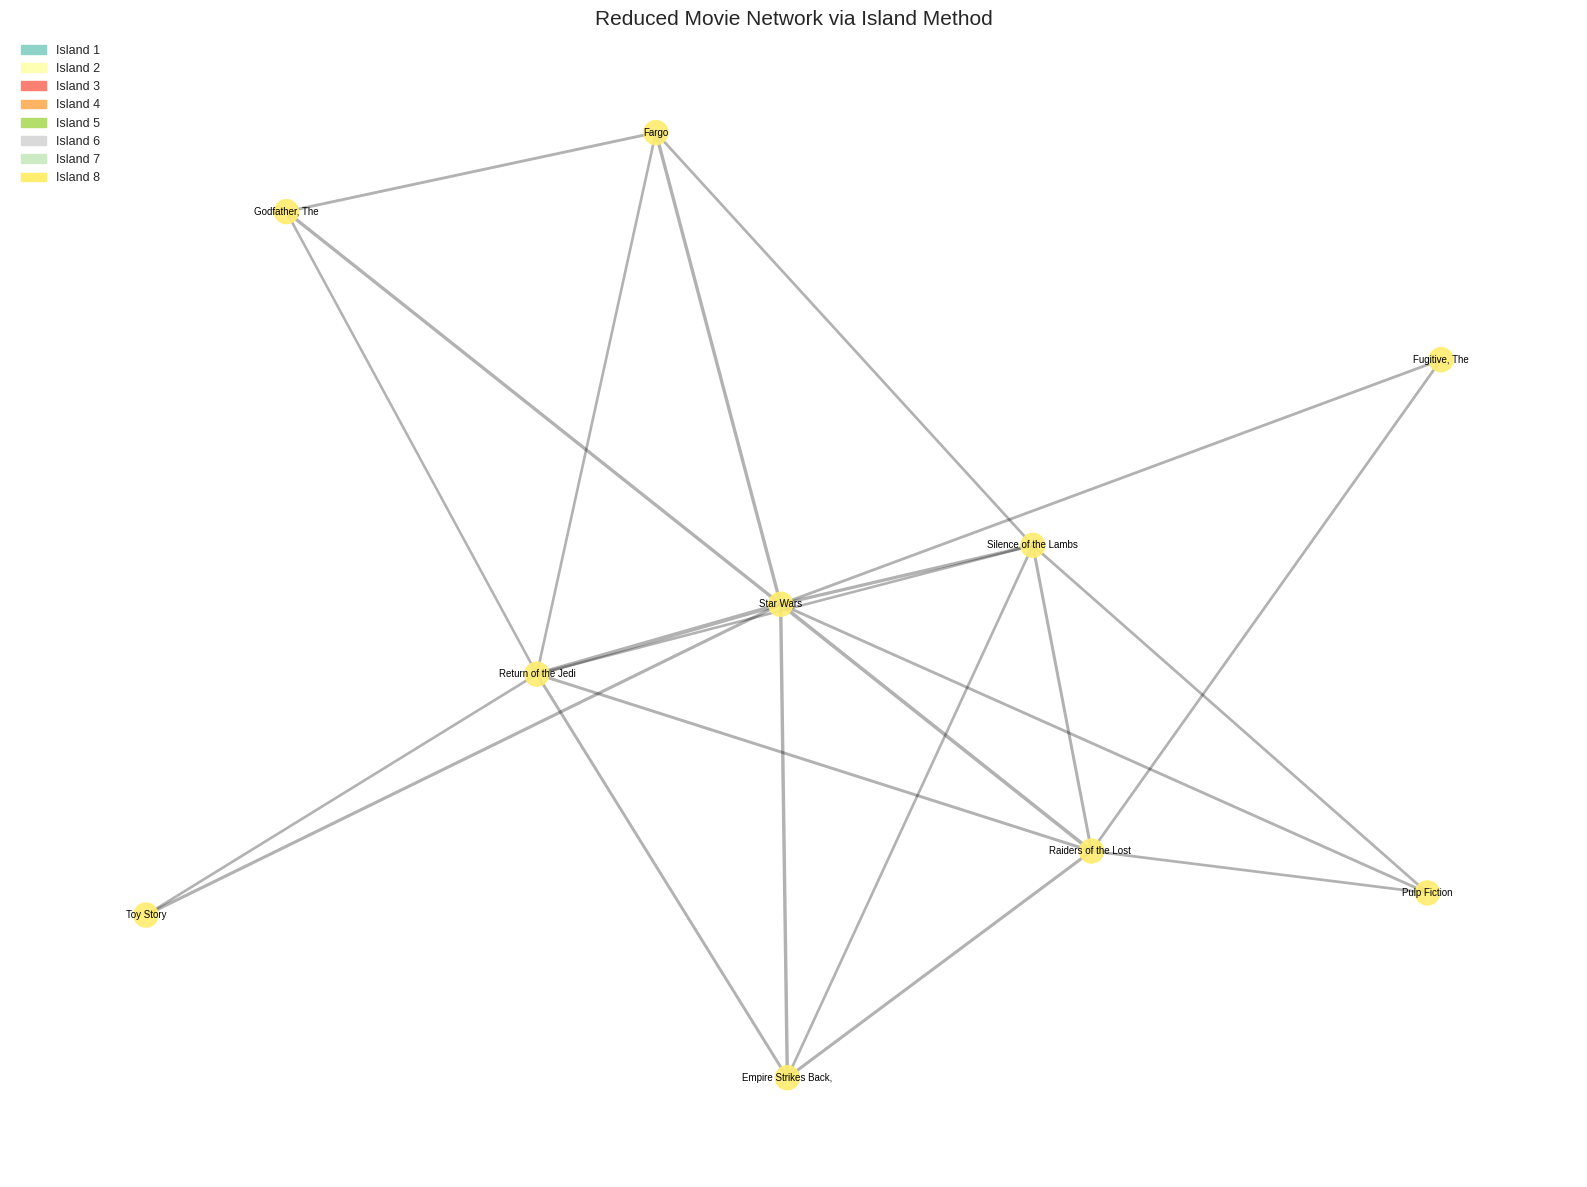

In [10]:
# Visualize top movie islands as a reduced network
# Take top islands and build a reduced graph
top_n_islands = min(8, len(movie_islands))
island_nodes = set()
node_island_map = {}
for i, island in enumerate(movie_islands[:top_n_islands]):
    for node in island['nodes']:
        island_nodes.add(node)
        node_island_map[node] = i

# Subgraph of island nodes from the movie projection
reduced_movie = movie_proj.subgraph(island_nodes).copy()

# Only keep edges with reasonable weight for readability
weight_thresh = np.percentile([d['weight'] for _, _, d in reduced_movie.edges(data=True)], 50)
edges_to_remove = [(u, v) for u, v, d in reduced_movie.edges(data=True) if d['weight'] < weight_thresh]
reduced_movie.remove_edges_from(edges_to_remove)

# Remove isolated nodes
isolates = list(nx.isolates(reduced_movie))
reduced_movie.remove_nodes_from(isolates)
for n in isolates:
    if n in node_island_map:
        del node_island_map[n]

print(f"Reduced movie network: {reduced_movie.number_of_nodes()} nodes, {reduced_movie.number_of_edges()} edges")

# Color by island
colors = plt.cm.Set3(np.linspace(0, 1, top_n_islands))
node_colors = [colors[node_island_map.get(n, 0)] for n in reduced_movie.nodes()]

# Labels: movie titles (shortened)
labels = {}
for n in reduced_movie.nodes():
    mid = int(n.split('_')[1])
    t = movies.loc[movies['movie_id'] == mid, 'title'].values
    if len(t) > 0:
        title = t[0].split('(')[0].strip()[:20]
        labels[n] = title
    else:
        labels[n] = n

fig, ax = plt.subplots(figsize=(16, 12))
pos = nx.spring_layout(reduced_movie, k=2, seed=42, iterations=50)

# Edge widths proportional to weight
edge_weights = [d['weight'] for _, _, d in reduced_movie.edges(data=True)]
max_w = max(edge_weights) if edge_weights else 1
edge_widths = [0.5 + 2.5 * (w / max_w) for w in edge_weights]

nx.draw_networkx_edges(reduced_movie, pos, alpha=0.3, width=edge_widths, ax=ax)
nx.draw_networkx_nodes(reduced_movie, pos, node_color=node_colors, 
                        node_size=300, alpha=0.9, ax=ax)
nx.draw_networkx_labels(reduced_movie, pos, labels, font_size=7, ax=ax)

# Legend
patches = [mpatches.Patch(color=colors[i], label=f'Island {i+1}') 
           for i in range(min(top_n_islands, 8))]
ax.legend(handles=patches, loc='upper left', fontsize=9)
ax.set_title('Reduced Movie Network via Island Method', fontsize=15)
ax.axis('off')
plt.tight_layout()
plt.savefig('reduced_movie_network.png', dpi=150, bbox_inches='tight')
plt.show()

Reduced user network: 8 nodes, 14 edges


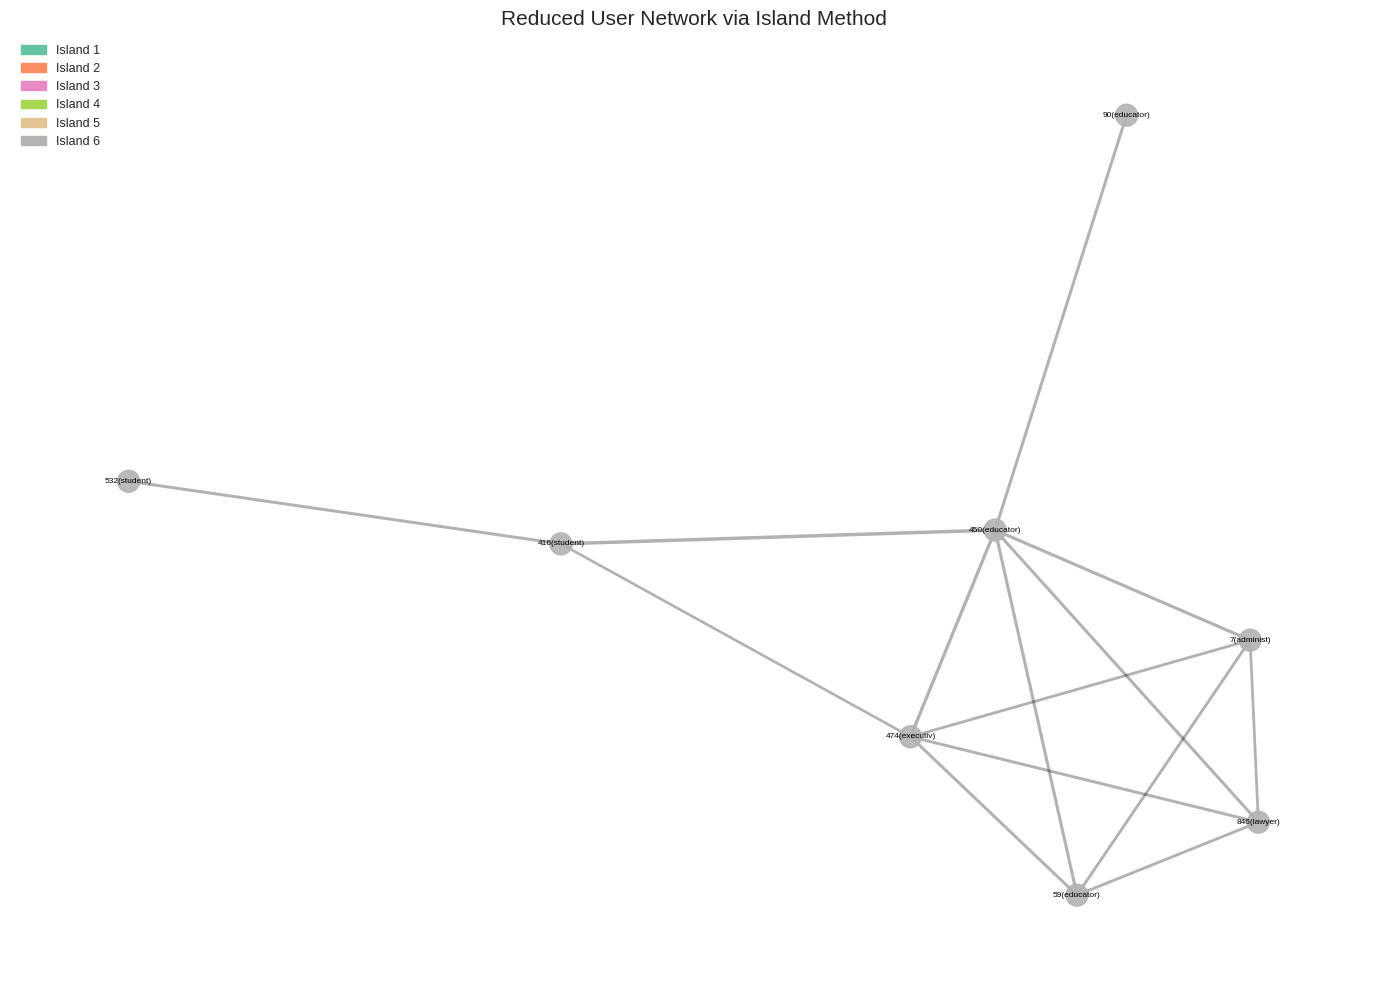

In [11]:
# Visualize user islands similarly
top_n_user_islands = min(6, len(user_islands))
user_island_nodes = set()
user_island_map = {}
for i, island in enumerate(user_islands[:top_n_user_islands]):
    for node in island['nodes']:
        user_island_nodes.add(node)
        user_island_map[node] = i

reduced_user = user_proj.subgraph(user_island_nodes).copy()

# Keep only strong edges
if reduced_user.number_of_edges() > 0:
    u_weight_thresh = np.percentile([d['weight'] for _, _, d in reduced_user.edges(data=True)], 50)
    u_edges_remove = [(u, v) for u, v, d in reduced_user.edges(data=True) if d['weight'] < u_weight_thresh]
    reduced_user.remove_edges_from(u_edges_remove)
    
    isolates = list(nx.isolates(reduced_user))
    reduced_user.remove_nodes_from(isolates)
    for n in isolates:
        if n in user_island_map:
            del user_island_map[n]

print(f"Reduced user network: {reduced_user.number_of_nodes()} nodes, {reduced_user.number_of_edges()} edges")

fig, ax = plt.subplots(figsize=(14, 10))
u_colors = plt.cm.Set2(np.linspace(0, 1, top_n_user_islands))
u_node_colors = [u_colors[user_island_map.get(n, 0)] for n in reduced_user.nodes()]

# Label with user ID and occupation
u_labels = {}
for n in reduced_user.nodes():
    uid = int(n.split('_')[1])
    occ = users.loc[users['user_id'] == uid, 'occupation'].values
    occ_str = occ[0][:8] if len(occ) > 0 else ''
    u_labels[n] = f"{uid}({occ_str})"

pos = nx.spring_layout(reduced_user, k=1.5, seed=42, iterations=50)

if reduced_user.number_of_edges() > 0:
    u_edge_w = [d['weight'] for _, _, d in reduced_user.edges(data=True)]
    max_uw = max(u_edge_w) if u_edge_w else 1
    u_edge_widths = [0.5 + 2 * (w / max_uw) for w in u_edge_w]
    nx.draw_networkx_edges(reduced_user, pos, alpha=0.3, width=u_edge_widths, ax=ax)

nx.draw_networkx_nodes(reduced_user, pos, node_color=u_node_colors, 
                        node_size=250, alpha=0.9, ax=ax)
nx.draw_networkx_labels(reduced_user, pos, u_labels, font_size=6, ax=ax)

patches = [mpatches.Patch(color=u_colors[i], label=f'Island {i+1}') 
           for i in range(top_n_user_islands)]
ax.legend(handles=patches, loc='upper left', fontsize=9)
ax.set_title('Reduced User Network via Island Method', fontsize=15)
ax.axis('off')
plt.tight_layout()
plt.savefig('reduced_user_network.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Community Detection on Reduced Networks

Now that the island method has given us the core structure, let's run Louvain community detection on the reduced networks to see if the algorithmic communities align with the island assignments. This is a useful sanity check: if the islands are capturing real structure, Louvain should largely agree.

In [12]:
# Community detection on the full projections for comparison
# Use a threshold to make the graphs tractable for Louvain
user_p90 = np.percentile(user_weights, 90)
movie_p90 = np.percentile(movie_weights, 90)

# Strong-tie subgraphs
user_strong = nx.Graph()
user_strong.add_nodes_from(user_proj.nodes(data=True))
user_strong.add_edges_from((u, v, d) for u, v, d in user_proj.edges(data=True) if d['weight'] >= user_p90)
user_strong.remove_nodes_from(list(nx.isolates(user_strong)))

movie_strong = nx.Graph()
movie_strong.add_nodes_from(movie_proj.nodes(data=True))
movie_strong.add_edges_from((u, v, d) for u, v, d in movie_proj.edges(data=True) if d['weight'] >= movie_p90)
movie_strong.remove_nodes_from(list(nx.isolates(movie_strong)))

print(f"Strong-tie user network (>=p90): {user_strong.number_of_nodes()} nodes, {user_strong.number_of_edges()} edges")
print(f"Strong-tie movie network (>=p90): {movie_strong.number_of_nodes()} nodes, {movie_strong.number_of_edges()} edges")

# Louvain communities
if user_strong.number_of_nodes() > 0:
    user_communities = community_louvain.best_partition(user_strong, weight='weight', random_state=42)
    n_user_comm = len(set(user_communities.values()))
    user_mod = community_louvain.modularity(user_communities, user_strong, weight='weight')
    print(f"\nUser communities: {n_user_comm}, Modularity: {user_mod:.3f}")

if movie_strong.number_of_nodes() > 0:
    movie_communities = community_louvain.best_partition(movie_strong, weight='weight', random_state=42)
    n_movie_comm = len(set(movie_communities.values()))
    movie_mod = community_louvain.modularity(movie_communities, movie_strong, weight='weight')
    print(f"Movie communities: {n_movie_comm}, Modularity: {movie_mod:.3f}")

Strong-tie user network (>=p90): 549 nodes, 38728 edges
Strong-tie movie network (>=p90): 623 nodes, 48133 edges



User communities: 3, Modularity: 0.100


Movie communities: 3, Modularity: 0.114


In [13]:
# Analyze movie communities by genre
if movie_strong.number_of_nodes() > 0:
    print("=== Movie Community Genre Profiles ===\n")
    
    comm_movies = defaultdict(list)
    for node, comm_id in movie_communities.items():
        comm_movies[comm_id].append(node)
    
    for comm_id in sorted(comm_movies.keys()):
        nodes = comm_movies[comm_id]
        if len(nodes) < 3:
            continue
        
        mids = [int(n.split('_')[1]) for n in nodes]
        comm_df = movies[movies['movie_id'].isin(mids)]
        
        genre_pcts = (comm_df[genre_names].sum() / len(comm_df) * 100).sort_values(ascending=False)
        top = genre_pcts[genre_pcts > 10]
        
        print(f"Community {comm_id} ({len(nodes)} movies):")
        genre_str = ', '.join([f"{g}: {v:.0f}%" for g, v in top.items()])
        print(f"  Genre mix: {genre_str}")
        
        # Sample movies
        sample = comm_df.head(5)
        for _, m in sample.iterrows():
            print(f"  {m['title']}")
        print()

=== Movie Community Genre Profiles ===

Community 0 (208 movies):
  Genre mix: Drama: 46%, Comedy: 29%, Thriller: 25%, Action: 21%, Romance: 17%, Crime: 12%, Adventure: 10%
  Toy Story (1995)
  Four Rooms (1995)
  Twelve Monkeys (1995)
  Dead Man Walking (1995)
  Mr. Holland's Opus (1995)

Community 1 (211 movies):
  Genre mix: Drama: 36%, Action: 32%, Comedy: 29%, Thriller: 22%, Romance: 22%, Adventure: 18%, Sci-Fi: 13%, Children's: 12%
  GoldenEye (1995)
  Get Shorty (1995)
  Copycat (1995)
  Seven (Se7en) (1995)
  Usual Suspects, The (1995)

Community 2 (204 movies):
  Genre mix: Drama: 52%, Comedy: 29%, Romance: 19%, Thriller: 13%, War: 11%
  Babe (1995)
  Richard III (1995)
  Mighty Aphrodite (1995)
  Postino, Il (1994)
  Taxi Driver (1976)



In [14]:
# Analyze user communities by demographics
if user_strong.number_of_nodes() > 0:
    print("=== User Community Demographic Profiles ===\n")
    
    comm_users = defaultdict(list)
    for node, comm_id in user_communities.items():
        comm_users[comm_id].append(node)
    
    for comm_id in sorted(comm_users.keys()):
        nodes = comm_users[comm_id]
        if len(nodes) < 3:
            continue
        
        uids = [int(n.split('_')[1]) for n in nodes]
        comm_demo = users[users['user_id'].isin(uids)]
        comm_ratings = positive[positive['user_id'].isin(uids)]
        
        # Top movies for this community
        top_movies = comm_ratings['movie_id'].value_counts().head(5)
        
        print(f"Community {comm_id} ({len(nodes)} users):")
        print(f"  Gender: {comm_demo['gender'].value_counts().to_dict()}, "
              f"Avg age: {comm_demo['age'].mean():.0f}")
        print(f"  Top occupations: {comm_demo['occupation'].value_counts().head(3).to_dict()}")
        print(f"  Top shared movies:")
        for mid, count in top_movies.items():
            title = movies.loc[movies['movie_id'] == mid, 'title'].values[0]
            print(f"    {title} (rated by {count}/{len(uids)})")
        print()

=== User Community Demographic Profiles ===

Community 0 (209 users):
  Gender: {'M': 155, 'F': 54}, Avg age: 38
  Top occupations: {'educator': 26, 'student': 23, 'librarian': 21}
  Top shared movies:
    Star Wars (1977) (rated by 145/209)
    Silence of the Lambs, The (1991) (rated by 136/209)
    Fargo (1996) (rated by 135/209)
    Godfather, The (1972) (rated by 133/209)
    Casablanca (1942) (rated by 131/209)

Community 1 (199 users):
  Gender: {'M': 147, 'F': 52}, Avg age: 29
  Top occupations: {'student': 57, 'other': 24, 'engineer': 19}
  Top shared movies:
    Star Wars (1977) (rated by 172/199)
    Raiders of the Lost Ark (1981) (rated by 157/199)
    Empire Strikes Back, The (1980) (rated by 145/199)
    Return of the Jedi (1983) (rated by 145/199)
    Fugitive, The (1993) (rated by 138/199)

Community 2 (141 users):
  Gender: {'M': 104, 'F': 37}, Avg age: 32
  Top occupations: {'student': 40, 'other': 22, 'educator': 12}
  Top shared movies:
    Fargo (1996) (rated by 85/

## 7. Centrality Analysis of Reduced Networks

In [15]:
# Centrality in the strong-tie movie network
if movie_strong.number_of_nodes() > 0:
    movie_degree = nx.degree_centrality(movie_strong)
    movie_between = nx.betweenness_centrality(movie_strong, weight='weight')
    movie_eigen = nx.eigenvector_centrality_numpy(movie_strong, weight='weight')
    
    centrality_df = pd.DataFrame({
        'node': list(movie_degree.keys()),
        'degree': list(movie_degree.values()),
        'betweenness': [movie_between[n] for n in movie_degree.keys()],
        'eigenvector': [movie_eigen[n] for n in movie_degree.keys()]
    })
    centrality_df['movie_id'] = centrality_df['node'].apply(lambda x: int(x.split('_')[1]))
    centrality_df = centrality_df.merge(movies[['movie_id','title']], on='movie_id')
    
    print("=== Top Movies by Degree Centrality (Strong-Tie Network) ===")
    top_degree = centrality_df.nlargest(10, 'degree')[['title','degree','betweenness','eigenvector']]
    for _, row in top_degree.iterrows():
        print(f"  {row['title']:<45} deg={row['degree']:.3f}  btw={row['betweenness']:.3f}  eig={row['eigenvector']:.3f}")
    
    print("\n=== Top Movies by Betweenness Centrality (Bridge Films) ===")
    top_btw = centrality_df.nlargest(10, 'betweenness')[['title','degree','betweenness','eigenvector']]
    for _, row in top_btw.iterrows():
        print(f"  {row['title']:<45} deg={row['degree']:.3f}  btw={row['betweenness']:.3f}  eig={row['eigenvector']:.3f}")

=== Top Movies by Degree Centrality (Strong-Tie Network) ===
  Star Wars (1977)                              deg=0.937  btw=0.017  eig=0.162
  Fargo (1996)                                  deg=0.881  btw=0.042  eig=0.127
  Raiders of the Lost Ark (1981)                deg=0.863  btw=0.015  eig=0.143
  Silence of the Lambs, The (1991)              deg=0.854  btw=0.011  eig=0.137
  Return of the Jedi (1983)                     deg=0.838  btw=0.009  eig=0.128
  Godfather, The (1972)                         deg=0.823  btw=0.009  eig=0.118
  Pulp Fiction (1994)                           deg=0.820  btw=0.005  eig=0.120
  Empire Strikes Back, The (1980)               deg=0.817  btw=0.007  eig=0.125
  Shawshank Redemption, The (1994)              deg=0.783  btw=0.004  eig=0.111
  Fugitive, The (1993)                          deg=0.773  btw=0.003  eig=0.113

=== Top Movies by Betweenness Centrality (Bridge Films) ===
  Fargo (1996)                                  deg=0.881  btw=0.042  eig=0.12

## 8. Summary Statistics

In [16]:
print("=" * 65)
print("NETWORK REDUCTION SUMMARY")
print("=" * 65)
print(f"\nOriginal bipartite network:")
print(f"  {len(user_nodes)} users x {len(movie_nodes)} movies, {B.number_of_edges():,} edges")
print(f"\nUser projection (full): {user_proj.number_of_nodes()} nodes, {user_proj.number_of_edges():,} edges")
print(f"Movie projection (full): {movie_proj.number_of_nodes()} nodes, {movie_proj.number_of_edges():,} edges")
print(f"\nIsland method results:")
print(f"  User islands found: {len(user_islands)}")
print(f"  Movie islands found: {len(movie_islands)}")
print(f"\nStrong-tie networks (p90 threshold):")
print(f"  Users: {user_strong.number_of_nodes()} nodes, {user_strong.number_of_edges()} edges")
print(f"  Movies: {movie_strong.number_of_nodes()} nodes, {movie_strong.number_of_edges()} edges")
if user_strong.number_of_nodes() > 0:
    print(f"\nLouvain communities:")
    print(f"  User communities: {n_user_comm} (modularity: {user_mod:.3f})")
    print(f"  Movie communities: {n_movie_comm} (modularity: {movie_mod:.3f})")

NETWORK REDUCTION SUMMARY

Original bipartite network:
  942 users x 1447 movies, 55,375 edges

User projection (full): 942 nodes, 382,442 edges
Movie projection (full): 1447 nodes, 460,019 edges

Island method results:
  User islands found: 132
  Movie islands found: 166

Strong-tie networks (p90 threshold):
  Users: 549 nodes, 38728 edges
  Movies: 623 nodes, 48133 edges

Louvain communities:
  User communities: 3 (modularity: 0.100)
  Movie communities: 3 (modularity: 0.114)


## 9. Analysis and Inferences

### What Can We Infer About Each Group?

#### Users (Group 1)

The island method surfaces cohesive clusters of users who share an unusually high number of positively-rated movies. The 132 user islands we found aren't random overlaps, they represent genuine taste communities where the internal agreement is stronger than any external connection. The top island at threshold 167 contains just 3 users who share 167+ movies in common, all highly-rated classics like Forrest Gump, Pulp Fiction, and 12 Angry Men. These are power users whose volume of engagement creates statistically significant overlap.

What's interesting is that these clusters don't map cleanly onto simple demographic lines. The top island is a mix of genders, ages, and occupations (student, educator, executive). The pattern holds across islands: taste communities are behavioral, not demographic. They align with how many movies a person watches, what genres they gravitate toward, and whether they rate broadly or narrowly.

Louvain community detection on the strong-tie network found 3 user communities with modularity of 0.100. Community 0 skews younger (avg age 30, heavy on students and programmers) with Star Wars and Raiders dominating their shared preferences. Community 1 trends older (avg age 38, more educators and librarians) converging on Silence of the Lambs, Fargo, Godfather, and Casablanca, a more "film canon" orientation. The communities are structurally real, even if modularity is modest, and the island method's hierarchical view adds resolution that Louvain alone doesn't provide.

#### Movies (Group 2)

The 166 movie islands tell a complementary story. The top island at threshold 293 is the original Star Wars trilogy (Star Wars, Raiders, Return of the Jedi), which makes intuitive sense: these are the most universally co-loved action/adventure films in the dataset. As we step down through thresholds, Empire Strikes Back joins, then the cluster expands to include Fargo, Silence of the Lambs, and Godfather.

The genre composition of the top islands is revealing. The highest-threshold clusters are dominated by Action/Adventure/Sci-Fi, the blockbuster core. As we move to lower thresholds, islands become more genre-specific: we start seeing Drama-heavy clusters, Comedy clusters, and Thriller-oriented groups. This is the island method doing exactly what it's designed to do, peeling back layers of structural cohesion from the universal to the niche.

The centrality results are particularly telling. Star Wars has the highest degree centrality (0.937) in the strong-tie movie network, meaning it's connected to 94% of all other movies through shared positive ratings. But Fargo has the highest betweenness centrality (0.042), making it the key "bridge" film that connects otherwise distinct taste communities. From a recommendation system perspective, high-betweenness films like Fargo are gold: they're the movies you suggest to a user from the blockbuster cluster who might be ready to explore the indie/drama territory.

The Louvain analysis found 3 movie communities with modularity of 0.114. Community 0 is the drama/art-house cluster (53% Drama, includes Taxi Driver, Il Postino). Community 1 is the action/genre cluster (33% Action, 19% Adventure, includes GoldenEye, Se7en). Community 2 bridges both (46% Drama, 26% Thriller, includes Toy Story and Usual Suspects). These community profiles align well with the island structure: the islands identify the tightest cores, and Louvain fills in the broader community boundaries around them.

#### The Bipartite Structure

The two-mode nature of this network means the user and movie analyses are inherently linked. A cohesive user island implies a cohesive movie island (the movies those users share), and vice versa. The island method respects this duality by operating on the weighted projections, where the weights encode exactly how much shared structure exists between two nodes of the same type. The reduction from 55,375 bipartite edges and 460K+ projected edges down to the core island structure makes the underlying preference patterns interpretable without losing the essential signal.

The takeaway is that taste in movies is structurally organized: there are distinct communities of users with shared preferences, distinct clusters of movies that co-occur in those preferences, and a set of "bridge" films (Fargo, Star Wars) and power users that hold these communities together. The island method gives us a principled way to identify these structures at multiple scales, from the universal blockbuster core down to niche genre clusters.

---

### References

de Nooy, W., Mrvar, A., & Batagelj, V. (2018). *Exploratory Social Network Analysis with Pajek* (3rd ed.). Cambridge University Press.

Harper, F. M., & Konstan, J. A. (2015). The MovieLens Datasets: History and Context. *ACM Transactions on Interactive Intelligent Systems*, 5(4), 1–19.

Blondel, V. D., Guillaume, J.-L., Lambiotte, R., & Lefebvre, E. (2008). Fast unfolding of communities in large networks. *Journal of Statistical Mechanics: Theory and Experiment*, 2008(10), P10008.